In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import matplotlib. ticker as ticker
import scipy.stats as stats
import matplotlib.cm as cm

In [2]:
import os
import gc
import time
import pandas as pd
from sqlalchemy import create_engine


# ==========================
# Create SQLite Database
# ==========================

engine = create_engine("sqlite:///inventory.db")

# ==========================
# Function to ingest large CSV in chunks
# ==========================

def ingest_large_csv(file_path, table_name, engine, chunksize=50000):
    first_chunk = True

    for chunk in pd.read_csv(file_path, chunksize=chunksize):

        chunk.to_sql(
            table_name,
            con=engine,
            if_exists="replace" if first_chunk else "append",
            index=False
        )

        first_chunk = False

        # Free memory
        del chunk
        gc.collect()

# ==========================
# Load CSV files
# ==========================

def load_raw_data():

    start = time.time()

    dataset_path = "/content/drive/MyDrive/dataset"

    csv_files = [
        f for f in os.listdir(dataset_path)
        if f.endswith(".csv")
    ]

    if not csv_files:
        print("No CSV files found.")
        return

    for file in csv_files:

        file_path = os.path.join(dataset_path, file)
        table_name = os.path.splitext(file)[0]

        try:
            size_mb = os.path.getsize(file_path) / (1024 * 1024)
            print(f"\nProcessing: {file}")
            print(f"Size: {size_mb:.2f} MB")

            ingest_large_csv(file_path, table_name, engine)

            print(f"Loaded: {table_name}")

        except Exception as e:
            print(f"Error processing {file}")
            print(e)

        gc.collect()

    end = time.time()

    print("\nDatabase Ingestion Completed")
    print(f"Total Time: {(end - start):.2f} seconds")

# ==========================
# Run Ingestion
# ==========================

load_raw_data()

# ==========================
# Show Tables
# ==========================

tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    engine
)

print("\nTables in Database:")
print(tables)

# ==========================
# Read one table (Optional)
# ==========================

if not tables.empty:

    first_table = tables.iloc[0, 0]

    print(f"\nContents of '{first_table}'")

    df = pd.read_sql_query(
        f"SELECT * FROM {first_table} LIMIT 5;",
        engine
    )

    print(df)

    del df
    gc.collect()


Processing: begin_inventory.csv
Size: 16.64 MB
Loaded: begin_inventory

Processing: purchase_prices.csv
Size: 1.00 MB
Loaded: purchase_prices

Processing: end_inventory.csv
Size: 18.10 MB
Loaded: end_inventory

Processing: vendor_invoice.csv
Size: 0.49 MB
Loaded: vendor_invoice

Processing: vendor_sales_summary.csv
Size: 2.04 MB
Loaded: vendor_sales_summary

Processing: purchases.csv
Size: 344.83 MB
Loaded: purchases

Processing: sales.csv
Size: 1522.76 MB
Loaded: sales

Database Ingestion Completed
Total Time: 364.85 seconds

Tables in Database:
                   name
0       begin_inventory
1       purchase_prices
2         end_inventory
3        vendor_invoice
4  vendor_sales_summary
5             purchases
6                 sales

Contents of 'begin_inventory'
         InventoryId  Store          City  Brand                  Description  \
0  1_HARDERSFIELD_58      1  HARDERSFIELD     58  Gekkeikan Black & Gold Sake   
1  1_HARDERSFIELD_60      1  HARDERSFIELD     60       Canadi

In [4]:
tables = pd.read_sql_query(
    "SELECT name FROM sqlite_master WHERE type='table';",
    engine
)

tables

,name
0,begin_inventory
1,purchase_prices
2,end_inventory
3,vendor_invoice
4,vendor_sales_summary
5,purchases
6,sales


In [5]:
for table in tables["name"]:
    print('-'*50, f" {table}",'-'*50)
    print(pd.read_sql(f"SELECT COUNT(*) AS record_count FROM {table}", engine))

--------------------------------------------------  begin_inventory --------------------------------------------------
   record_count
0        206529
--------------------------------------------------  purchase_prices --------------------------------------------------
   record_count
0         12261
--------------------------------------------------  end_inventory --------------------------------------------------
   record_count
0        224489
--------------------------------------------------  vendor_invoice --------------------------------------------------
   record_count
0          5543
--------------------------------------------------  vendor_sales_summary --------------------------------------------------
   record_count
0         10692
--------------------------------------------------  purchases --------------------------------------------------
   record_count
0       2372474
--------------------------------------------------  sales ----------------------------------------

In [6]:
for table in tables["name"]:
    print('-'*50, f" {table}",'-'*50)
    display(pd.read_sql(f"SELECT * FROM {table} LIMIT 5", engine))

--------------------------------------------------  begin_inventory --------------------------------------------------


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


--------------------------------------------------  purchase_prices --------------------------------------------------


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


--------------------------------------------------  end_inventory --------------------------------------------------


...

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesPrice,TotalSalesDollars,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,672819.31,5101919.51,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,561512.37,4819073.49,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,461140.15,4538120.60,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,420050.01,4475972.88,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,545778.28,4223107.62,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


--------------------------------------------------  purchases --------------------------------------------------


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


--------------------------------------------------  sales --------------------------------------------------


,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-01,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
1,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,2,32.98,16.49,2024-01-02,750.0,1,1.57,12546,JIM BEAM BRANDS COMPANY
2,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,16.49,16.49,2024-01-03,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
3,1_HARDERSFIELD_1004,1,1004,Jim Beam w/2 Rocks Glasses,750mL,1,14.49,14.49,2024-01-08,750.0,1,0.79,12546,JIM BEAM BRANDS COMPANY
4,1_HARDERSFIELD_1005,1,1005,Maker's Mark Combo Pack,375mL 2 Pk,2,69.98,34.99,2024-01-09,375.0,1,0.79,12546,JIM BEAM BRANDS COMPANY


In [7]:
purchases = pd.read_sql(f"SELECT * FROM purchases where vendornumber=4466", engine)
purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
1,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
2,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
3,38_GOULCREST_5215,38,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-07,2024-01-19,2024-02-26,9.41,6,56.46,1
4,59_CLAETHORPES_5215,59,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8207,2023-12-27,2024-01-05,2024-01-19,2024-02-26,9.41,6,56.46,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2187,81_PEMBROKE_5215,81,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,13595,2024-12-20,2024-12-29,2025-01-04,2025-02-10,9.41,6,56.46,1
2188,62_KILMARNOCK_5255,62,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,13595,2024-12-20,2024-12-28,2025-01-04,2025-02-10,9.35,5,46.75,1
2189,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,13595,2024-12-20,2024-12-28,2025-01-04,2025-02-10,9.41,5,47.05,1
2190,6_GOULCREST_5215,6,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,13595,2024-12-20,2024-12-31,2025-01-04,2025-02-10,9.41,6,56.46,1


In [8]:
purchase_prices = pd.read_sql("""SELECT * FROM purchase_prices where vendornumber=4466""", engine)
purchase_prices

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,5215,TGI Fridays Long Island Iced,12.99,1750mL,1750,1,9.41,4466,AMERICAN VINTAGE BEVERAGE
1,5255,TGI Fridays Ultimte Mudslide,12.99,1750mL,1750,1,9.35,4466,AMERICAN VINTAGE BEVERAGE
2,3140,TGI Fridays Orange Dream,14.99,1750mL,1750,1,11.19,4466,AMERICAN VINTAGE BEVERAGE


In [9]:
vendor_invoice = pd.read_sql("""SELECT * FROM vendor_invoice where vendornumber=4466""", engine)
vendor_invoice

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-19,8207,2023-12-27,2024-02-26,335,3142.33,16.97,None
2,4466,AMERICAN VINTAGE BEVERAGE,2024-01-18,8307,2024-01-03,2024-02-18,41,383.35,1.99,None
3,4466,AMERICAN VINTAGE BEVERAGE,2024-01-27,8469,2024-01-14,2024-03-11,72,673.20,3.30,None
4,4466,AMERICAN VINTAGE BEVERAGE,2024-02-04,8532,2024-01-19,2024-03-15,79,740.21,3.48,None
5,4466,AMERICAN VINTAGE BEVERAGE,2024-02-09,8604,2024-01-24,2024-03-15,347,3261.37,17.61,None
6,4466,AMERICAN VINTAGE BEVERAGE,2024-02-17,8793,2024-02-05,2024-04-02,72,675.36,3.17,None
7,4466,AMERICAN VINTAGE BEVERAGE,2024-03-01,8892,2024-02-12,2024-03-28,117,1096.05,5.15,None
8,4466,AMERICAN VINTAGE BEVERAGE,2024-03-07,8995,2024-02-19,2024-04-02,129,1209.27,5.44,None
9,4466,AMERICAN VINTAGE BEVERAGE,2024-03-12,9033,2024-02-22,2024-04-16,147,1377.87,6.61,None


In [10]:
sales = pd.read_sql("""SELECT * FROM sales where vendorno=4466""", engine)
sales

,InventoryId,Store,Brand,Description,Size,SalesQuantity,SalesDollars,SalesPrice,SalesDate,Volume,Classification,ExciseTax,VendorNo,VendorName
0,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-09,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
1,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-12,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
2,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-15,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
3,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-21,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
4,1_HARDERSFIELD_5215,1,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-01-23,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9448,9_BLACKPOOL_5215,9,5215,TGI Fridays Long Island Iced,1.75L,1,12.99,12.99,2024-12-21,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
9449,9_BLACKPOOL_5255,9,5255,TGI Fridays Ultimte Mudslide,1.75L,1,12.99,12.99,2024-12-02,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
9450,9_BLACKPOOL_5255,9,5255,TGI Fridays Ultimte Mudslide,1.75L,1,12.99,12.99,2024-12-09,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE
9451,9_BLACKPOOL_5255,9,5255,TGI Fridays Ultimte Mudslide,1.75L,1,12.99,12.99,2024-12-23,1750.0,1,1.84,4466,AMERICAN VINTAGE BEVERAGE


In [11]:
purchases.groupby(['Brand','PurchasePrice'])[['Quantity','Dollars']].sum()

,,Quantity,Dollars
Brand,PurchasePrice,,
3140,11.19,4640,51921.60
5215,9.41,4923,46325.43
5255,9.35,6215,58110.25


In [12]:
purchase_prices

,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,5215,TGI Fridays Long Island Iced,12.99,1750mL,1750,1,9.41,4466,AMERICAN VINTAGE BEVERAGE
1,5255,TGI Fridays Ultimte Mudslide,12.99,1750mL,1750,1,9.35,4466,AMERICAN VINTAGE BEVERAGE
2,3140,TGI Fridays Orange Dream,14.99,1750mL,1750,1,11.19,4466,AMERICAN VINTAGE BEVERAGE


In [13]:
sales.groupby('Brand') [ ['SalesDollars', 'SalesPrice', 'SalesQuantity']].sum()

,SalesDollars,SalesPrice,SalesQuantity
Brand,,,
3140,50531.10,30071.85,3890
5215,60416.49,41542.02,4651
5255,79187.04,51180.60,6096


In [14]:
vendor_invoice.columns

Index(['VendorNumber', 'VendorName', 'InvoiceDate', 'PONumber', 'PODate',
       'PayDate', 'Quantity', 'Dollars', 'Freight', 'Approval'],
      dtype='object')

In [15]:
frieght_summury=pd.read_sql_query("""select VendorNumber, sum(Freight)
                                     from vendor_invoice
                                     group by VendorNumber """, engine)
frieght_summury

,VendorNumber,sum(Freight)
0,2,27.08
1,54,0.48
2,60,367.52
3,105,62.39
4,200,6.19
...,...,...
121,98450,856.02
122,99166,130.09
123,172662,178.34
124,173357,202.50


In [16]:
pd.read_sql_query("""SELECT
  p.VendorNumber,
  p.VendorName,
  p.Brand,
  p.PurchasePrice,
  pp.Volume,
  pp.Price as ActualPrice,
  SUM(p.Quantity) as TotalPurchaseQuantity,
  SUM(p.Dollars) as TotalPurchaseDollars
  FROM purchases p
  JOIN purchase_prices pp
  ON p.Brand = pp.Brand
  Where p.PurchasePrice > 0
  GROUP BY p.VendorNumber, p.VendorName, p.Brand
  ORDER BY TotalPurchaseDollars""", engine)

,VendorNumber,VendorName,Brand,PurchasePrice,Volume,ActualPrice,TotalPurchaseQuantity,TotalPurchaseDollars
0,7245,PROXIMO SPIRITS INC.,3065,0.71,50,0.99,1,0.71
1,3960,DIAGEO NORTH AMERICA INC,6127,1.47,200,1.99,1,1.47
2,3924,HEAVEN HILL DISTILLERIES,9123,0.74,50,0.99,2,1.48
3,8004,SAZERAC CO INC,5683,0.39,50,0.49,6,2.34
4,9815,WINE GROUP INC,8527,1.32,750,4.99,2,2.64
...,...,...,...,...,...,...,...,...
10687,3960,DIAGEO NORTH AMERICA INC,3545,21.89,1750,29.99,138109,3023206.01
10688,3960,DIAGEO NORTH AMERICA INC,4261,16.17,1750,22.99,201682,3261197.94
10689,17035,PERNOD RICARD USA,8068,18.24,1750,24.99,187407,3418303.68
10690,4425,MARTIGNETTI COMPANIES,3405,23.19,1750,28.99,164038,3804041.22


In [17]:
sales.columns

Index(['InventoryId', 'Store', 'Brand', 'Description', 'Size', 'SalesQuantity',
       'SalesDollars', 'SalesPrice', 'SalesDate', 'Volume', 'Classification',
       'ExciseTax', 'VendorNo', 'VendorName'],
      dtype='object')

In [18]:
pd.read_sql_query("""SELECT
  VendorNo,
  Brand,
  SUM(SalesDollars) as TotalSalesDollars,
  SUM(SalesPrice) as TotalSalesPrice,
  SUM(SalesQuantity) as TotalSalesQuanity,
  SUM(ExciseTax) as TotalExciseTax
  FROM sales
  GROUP BY VendorNo, Brand
  Order by TotalSalesDollars""", engine)

,VendorNo,Brand,TotalSalesDollars,TotalSalesPrice,TotalSalesQuanity,TotalExciseTax
0,8004,5287,9.800000e-01,0.98,2,0.10
1,9206,2773,9.900000e-01,0.99,1,0.05
2,3252,3933,1.980000e+00,0.99,2,0.10
3,3924,9123,1.980000e+00,0.99,2,0.10
4,10050,3623,1.980000e+00,1.98,2,0.10
...,...,...,...,...,...,...
11267,3960,3545,4.223108e+06,545778.28,135838,249587.83
11268,3960,4261,4.475973e+06,420050.01,200412,368242.80
11269,17035,8068,4.538121e+06,461140.15,187140,343854.07
11270,4425,3405,4.819073e+06,561512.37,160247,294438.66


In [ ]:
start = time.time()
final_table= pd.read_sql_query("""select
  pp. VendorNumber,
  pp.Brand,
  pp.Price as ActualPrice,
  pp.PurchasePrice,
  SUM(s.SalesQuantity) AS TotalSalesQuantity,
  SUM(s.SalesDollars) AS TotalSalesDollars,
  SUM(s.SalesPrice) AS TotalSalesPrice,
  SUM(s.ExciseTax) AS TotalExciseTax,
  SUM(vi.Quantity) AS TotalPurchaseQuantity,
  SUM(vi.Dollars) AS TotalPurchaseDollars,
  SUM(vi.Freight) AS TotalFreightCost
    FROM purchase_prices pp
    JOIN sales s
    ON pp. VendorNumber = s. VendorNo
    AND pp.Brand = s.Brand
    JOIN vendor_invoice vi
    ON pp. VendorNumber = vi. VendorNumber
    GROUP BY pp. VendorNumber, pp.Brand, pp. Price, pp. PurchasePrice """, engine)
end=time.time()
total_time = (end-start)/60

**THIS QUERY AS OPTIMIZED WAY**

In [19]:
vendor_sales_summary = pd.read_sql_query("""
WITH FreightSummary AS (
    SELECT
        VendorNumber,
        VendorName,
        SUM(Freight) AS FreightCost
    FROM vendor_invoice
    GROUP BY VendorNumber, VendorName
),

PurchaseSummary AS (
    SELECT
        p.VendorNumber,
        p.VendorName,
        p.Brand,
        p.Description,
        p.PurchasePrice,
        pp.Price AS ActualPrice,
        pp.Volume,
        SUM(p.Quantity) AS TotalPurchaseQuantity,
        SUM(p.Dollars) AS TotalPurchaseDollars
    FROM purchases p
    JOIN purchase_prices pp
        ON p.Brand = pp.Brand
    WHERE p.PurchasePrice > 0
    GROUP BY
        p.VendorNumber,
        p.VendorName,
        p.Brand,
        p.Description,
        p.PurchasePrice,
        pp.Price,
        pp.Volume
),

SalesSummary AS (
    SELECT
        VendorNo,
        Brand,
        SUM(SalesQuantity) AS TotalSalesQuantity,
        SUM(SalesDollars) AS TotalSalesDollars,
        SUM(SalesPrice) AS TotalSalesPrice,
        SUM(ExciseTax) AS TotalExciseTax
    FROM sales
    GROUP BY VendorNo, Brand
)

SELECT
    ps.VendorNumber,
    ps.VendorName,
    ps.Brand,
    ps.Description,
    ps.PurchasePrice,
    ps.ActualPrice,
    ps.Volume,
    ps.TotalPurchaseQuantity,
    ps.TotalPurchaseDollars,
    ss.TotalSalesQuantity,
    ss.TotalSalesDollars,
    ss.TotalSalesPrice,
    ss.TotalExciseTax,
    fs.FreightCost
FROM PurchaseSummary ps
LEFT JOIN SalesSummary ss
    ON ps.VendorNumber = ss.VendorNo
    AND ps.Brand = ss.Brand
LEFT JOIN FreightSummary fs
    ON ps.VendorNumber = fs.VendorNumber
ORDER BY ps.TotalPurchaseDollars DESC
""", engine)



In [20]:
vendor_sales_summary

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,209.32
2,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144719.92
3,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22
4,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12484,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41
12485,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62
12486,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87
12487,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07


In [21]:
vendor_sales_summary.dtypes

,0
VendorNumber,int64
VendorName,object
Brand,int64
Description,object
PurchasePrice,float64
ActualPrice,float64
Volume,object
TotalPurchaseQuantity,int64
TotalPurchaseDollars,float64
TotalSalesQuantity,float64


In [22]:
vendor_sales_summary.isnull().sum()

,0
VendorNumber,0
VendorName,0
Brand,0
Description,0
PurchasePrice,0
ActualPrice,0
Volume,0
TotalPurchaseQuantity,0
TotalPurchaseDollars,0
TotalSalesQuantity,209


In [23]:
vendor_sales_summary['VendorName'].unique()

array(['BROWN-FORMAN CORP          ', 'MARTIGNETTI COMPANIES',
       'PERNOD RICARD USA          ', 'DIAGEO NORTH AMERICA INC   ',
       'BACARDI USA INC            ', 'JIM BEAM BRANDS COMPANY    ',
       'MAJESTIC FINE WINES        ', 'ULTRA BEVERAGE COMPANY LLP ',
       'STOLI GROUP,(USA) LLC      ', 'PROXIMO SPIRITS INC.       ',
       'MOET HENNESSY USA INC      ', 'CAMPARI AMERICA            ',
       'SAZERAC CO INC             ', 'CONSTELLATION BRANDS INC   ',
       'M S WALKER INC             ', 'SAZERAC NORTH AMERICA INC. ',
       'PALM BAY INTERNATIONAL INC ', 'REMY COINTREAU USA INC     ',
       'SIDNEY FRANK IMPORTING CO  ', 'E & J GALLO WINERY         ',
       'WILLIAM GRANT & SONS INC   ', 'HEAVEN HILL DISTILLERIES   ',
       'DISARONNO INTERNATIONAL LLC', 'EDRINGTON AMERICAS         ',
       'CASTLE BRANDS CORP.        ', 'SOUTHERN WINE & SPIRITS NE ',
       'STE MICHELLE WINE ESTATES  ', 'TRINCHERO FAMILY ESTATES   ',
       'MHW LTD                    ', 'W

In [24]:
vendor_sales_summary['Description'].unique()

array(['Jack Daniels No 7 Black', "Tito's Handmade Vodka",
       'Absolut 80 Proof', ..., 'Crown Royal Apple',
       'Concannon Glen Ellen Wh Zin', 'The Club Strawbry Margarita'],
      dtype=object)

In [25]:
vendor_sales_summary['Volume']= vendor_sales_summary['Volume'].astype('float64')

In [26]:
vendor_sales_summary.fillna(0,inplace=True)

In [27]:
vendor_sales_summary['GrossProfit'] =vendor_sales_summary['TotalSalesPrice'] -  vendor_sales_summary['TotalPurchaseDollars']
vendor_sales_summary['GrossProfit']

,GrossProfit
0,-3138432.29
1,-3242528.85
2,-3242528.85
3,-2957163.53
4,-2841147.93
...,...
12484,8.32
12485,-0.87
12486,-0.49
12487,76.14


In [28]:
vendor_sales_summary['ProfitMargin'] = (vendor_sales_summary['GrossProfit']/vendor_sales_summary['TotalPurchaseDollars'])*100
vendor_sales_summary['ProfitMargin']

,ProfitMargin
0,-82.346500
1,-85.239057
2,-85.239057
3,-86.509679
4,-87.119763
...,...
12484,315.151515
12485,-37.179487
12486,-33.108108
12487,5179.591837


In [29]:
vendor_sales_summary['StockTurnover'] = vendor_sales_summary['TotalSalesQuantity']/vendor_sales_summary['TotalPurchaseQuantity']
vendor_sales_summary['StockTurnover']

,StockTurnover
0,0.979108
1,0.976890
2,0.976890
3,0.998575
4,0.993703
...,...
12484,2.500000
12485,22.333333
12486,1.000000
12487,72.000000


In [102]:
from IPython.display import display, HTML

# ============================================================
# 1. VENDORS WITH LOW INVENTORY TURNOVER
#    Identifies vendors whose average Stock Turnover is below 1.
#    Lower turnover indicates that inventory is moving slowly.
# ============================================================

low_turnover_vendors = (
    df[df["StockTurnover"] < 1]
    .groupby("VendorName")["StockTurnover"]
    .mean()
    .reset_index()
    .sort_values(by="StockTurnover", ascending=True)
)

# Display only the top 10 vendors with the lowest turnover
low_turnover_top10 = low_turnover_vendors.head(10)


# ============================================================
# 2. UNSOLD INVENTORY VALUE
#    Calculates the amount of capital currently locked in
#    unsold inventory for each vendor.
# ============================================================

df["UnsoldInventoryValue"] = (
    (df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"])
    * df["PurchasePrice"]
)

# Calculate total capital locked in unsold inventory
total_unsold_capital = df["UnsoldInventoryValue"].sum()

print(
    "Total Capital Locked in Unsold Inventory:",
    format_dollars(total_unsold_capital)
)

# Aggregate unsold inventory value by vendor
inventory_value_per_vendor = (
    df.groupby("VendorName")["UnsoldInventoryValue"]
    .sum()
    .reset_index()
    .sort_values(by="UnsoldInventoryValue", ascending=False)
)

# Keep numeric values for sorting, then format them for display
inventory_value_top10 = inventory_value_per_vendor.head(10).copy()

inventory_value_top10["UnsoldInventoryValue"] = (
    inventory_value_top10["UnsoldInventoryValue"]
    .apply(format_dollars)
)


# ============================================================
# 3. DISPLAY BOTH TABLES SIDE-BY-SIDE
# ============================================================

html = f"""
<div style="display: flex; gap: 40px; align-items: flex-start;">

    <div style="width: 48%;">
        <h3 style="color: #1f4e79;">
            Top 10 Vendors with Lowest Inventory Turnover
        </h3>
        <p>
            Vendors with an average stock turnover below 1,
            indicating slow-moving inventory.
        </p>
        {low_turnover_top10.to_html(index=False)}
    </div>

    <div style="width: 48%;">
        <h3 style="color: #8B0000;">
            Top 10 Vendors with Highest Capital Locked in Unsold Inventory
        </h3>
        <p>
            Vendors with the highest value of inventory that remains unsold.
        </p>
        {inventory_value_top10.to_html(index=False)}
    </div>

</div>
"""

display(HTML(html))

Total Capital Locked in Unsold Inventory:  2.71M


VendorName,StockTurnover
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569
WALPOLE MTN VIEW WINERY,0.820548


In [86]:
vendor_sales_summary['SalesToPurchaseRatio'] = vendor_sales_summary['TotalSalesDollars']/vendor_sales_summary['TotalPurchaseDollars']
vendor_sales_summary['SalesToPurchaseRatio']

,SalesToPurchaseRatio
0,1.338647
1,1.266830
2,1.266830
3,1.327594
4,1.372493
...,...
12484,6.041667
12485,28.059829
12486,1.337838
12487,97.469388


In [87]:
conn = engine.connect()

In [88]:
from sqlalchemy import text

conn = engine.connect()

conn.execute(text("""
    CREATE TABLE IF NOT EXISTS sales_summary (
        VendorNumber INT,
        VendorName VARCHAR(100),
        Brand INT,
        Description VARCHAR(100),
        PurchasePrice DECIMAL(10,2),
        ActualPrice DECIMAL(10,2),
        Volume DECIMAL(10,2),
        TotalPurchaseQuantity INT,
        TotalPurchaseDollars DECIMAL(15,2),
        TotalSalesQuantity INT,
        TotalSalesDollars DECIMAL(15,2),
        TotalSalesPrice DECIMAL(15,2),
        TotalExciseTax DECIMAL(15,2),
        FreightCost DECIMAL(15,2),
        GrossProfit DECIMAL(15,2),
        ProfitMargin DECIMAL(15,2),
        StockTurnover DECIMAL(15,2),
        SalesToPurchaseRatio DECIMAL(15,2),
        PRIMARY KEY (VendorNumber, Brand)
    );
"""))


In [33]:
vendor_sales_summary.to_sql('sales_summary', engine, if_exists = 'replace', index = False )

12489

In [34]:
pd.read_sql_query("select * from sales_summary",engine)

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,-3138432.29,-82.346500,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,209.32,-3242528.85,-85.239057,0.976890,1.266830
2,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144719.92,-3242528.85,-85.239057,0.976890,1.266830
3,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,-2957163.53,-86.509679,0.998575,1.327594
4,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,-2841147.93,-87.119763,0.993703,1.372493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12484,9815,WINE GROUP INC,8527,Concannon Glen Ellen Wh Zin,1.32,4.99,750.0,2,2.64,5.0,1.595000e+01,10.96,0.55,27100.41,8.32,315.151515,2.500000,6.041667
12485,8004,SAZERAC CO INC,5683,Dr McGillicuddy's Apple Pie,0.39,0.49,50.0,6,2.34,134.0,6.566000e+01,1.47,7.04,50293.62,-0.87,-37.179487,22.333333,28.059829
12486,3924,HEAVEN HILL DISTILLERIES,9123,Deep Eddy Vodka,0.74,0.99,50.0,2,1.48,2.0,1.980000e+00,0.99,0.10,14069.87,-0.49,-33.108108,1.000000,1.337838
12487,3960,DIAGEO NORTH AMERICA INC,6127,The Club Strawbry Margarita,1.47,1.99,200.0,1,1.47,72.0,1.432800e+02,77.61,15.12,257032.07,76.14,5179.591837,72.000000,97.469388


In [35]:
import sqlite3
import pandas as pd
import logging
import os


# ============================================================
# 1. LOGGING SETUP
# ============================================================

os.makedirs("logs", exist_ok=True)

logging.basicConfig(
    filename="logs/get_vendor_summary.log",
    level=logging.DEBUG,
    format="%(asctime)s - %(levelname)s - %(message)s",
    filemode="a"
)


# ============================================================
# 2. CREATE VENDOR SUMMARY
# ============================================================

def create_vendor_summary(conn):
    """
    Merge purchases, sales, and vendor invoice tables
    to create the overall vendor summary.
    """

    vendor_sales_summary = pd.read_sql_query("""

        WITH FreightSummary AS (

            SELECT
                VendorNumber,
                SUM(Freight) AS FreightCost

            FROM vendor_invoice

            GROUP BY VendorNumber
        ),


        PurchaseSummary AS (

            SELECT
                p.VendorNumber,
                p.VendorName,
                p.Brand,
                p.Description,
                p.PurchasePrice,
                pp.Price AS ActualPrice,
                pp.Volume,

                SUM(p.Quantity) AS TotalPurchaseQuantity,
                SUM(p.Dollars) AS TotalPurchaseDollars

            FROM purchases p

            JOIN purchase_prices pp
                ON p.Brand = pp.Brand

            WHERE p.PurchasePrice > 0

            GROUP BY
                p.VendorNumber,
                p.VendorName,
                p.Brand,
                p.Description,
                p.PurchasePrice,
                pp.Price,
                pp.Volume
        ),


        SalesSummary AS (

            SELECT
                VendorNo,
                Brand,

                SUM(SalesQuantity) AS TotalSalesQuantity,
                SUM(SalesDollars) AS TotalSalesDollars,
                SUM(SalesPrice) AS TotalSalesPrice,
                SUM(ExciseTax) AS TotalExciseTax

            FROM sales

            GROUP BY
                VendorNo,
                Brand
        )


        SELECT
            ps.VendorNumber,
            ps.VendorName,
            ps.Brand,
            ps.Description,
            ps.PurchasePrice,
            ps.ActualPrice,
            ps.Volume,

            ps.TotalPurchaseQuantity,
            ps.TotalPurchaseDollars,

            ss.TotalSalesQuantity,
            ss.TotalSalesDollars,
            ss.TotalSalesPrice,
            ss.TotalExciseTax,

            fs.FreightCost

        FROM PurchaseSummary ps

        LEFT JOIN SalesSummary ss
            ON ps.VendorNumber = ss.VendorNo
            AND ps.Brand = ss.Brand

        LEFT JOIN FreightSummary fs
            ON ps.VendorNumber = fs.VendorNumber

        ORDER BY
            ps.TotalPurchaseDollars DESC

    """, conn)

    logging.info("Vendor summary created successfully.")

    return vendor_sales_summary


# ============================================================
# 3. CLEAN DATA
# ============================================================

def clean_data(df):
    """
    Clean vendor summary data and create additional
    analytical columns.
    """

    # Convert Volume to numeric
    df["Volume"] = pd.to_numeric(
        df["Volume"],
        errors="coerce"
    )

    # Fill missing values with 0
    df.fillna(0, inplace=True)

    # Remove extra spaces from text columns
    df["VendorName"] = (
        df["VendorName"]
        .astype(str)
        .str.strip()
    )

    df["Description"] = (
        df["Description"]
        .astype(str)
        .str.strip()
    )

    # ========================================================
    # Create new analytical columns
    # ========================================================

    # Gross Profit
    df["GrossProfit"] = (
        df["TotalSalesDollars"]
        - df["TotalPurchaseDollars"]
    )

    # Profit Margin
    df["ProfitMargin"] = (
        df["GrossProfit"]
        / df["TotalSalesDollars"].replace(0, pd.NA)
    ) * 100

    # Stock Turnover
    df["StockTurnover"] = (
        df["TotalSalesQuantity"]
        / df["TotalPurchaseQuantity"].replace(0, pd.NA)
    )

    # Sales to Purchase Ratio
    df["SalesToPurchaseRatio"] = (
        df["TotalSalesDollars"]
        / df["TotalPurchaseDollars"].replace(0, pd.NA)
    )

    # Replace division-by-zero results with 0
    df.fillna(0, inplace=True)

    logging.info("Vendor summary cleaned successfully.")

    return df


# ============================================================
# 4. DATABASE PATH
# ============================================================

db_path = "/content/inventory.db"


# ============================================================
# 5. CONNECT TO DATABASE
# ============================================================

conn = sqlite3.connect(db_path)


try:

    # ========================================================
    # Create vendor summary
    # ========================================================

    vendor_summary = create_vendor_summary(conn)

    print("Vendor summary created successfully.")

    # ========================================================
    # Clean vendor summary
    # ========================================================

    vendor_summary = clean_data(vendor_summary)

    print("Vendor summary cleaned successfully.")

    # ========================================================
    # Show first 5 rows BEFORE saving
    # ========================================================

    print("\nFirst 5 rows:")
    display(vendor_summary.head())

    # ========================================================
    # Save to SQLite database
    # ========================================================

    vendor_summary.to_sql(
        "vendor_sales_summary",
        conn,
        if_exists="replace",
        index=False
    )

    # Commit changes
    conn.commit()

    print("\nDatabase updated successfully!")
    print(f"Database path: {db_path}")
    print(f"Rows inserted: {len(vendor_summary)}")
    print(f"Columns: {len(vendor_summary.columns)}")


except Exception as e:

    logging.exception(
        "Error while updating vendor summary."
    )

    print(f"\nError: {e}")


finally:

    conn.close()


# ============================================================
# 6. VERIFY DATA SAVED TO DATABASE
# ============================================================

print("\n" + "=" * 60)
print("VERIFYING DATA FROM SQLITE DATABASE")
print("=" * 60)

conn = sqlite3.connect(db_path)

try:

    # Read the saved table directly from SQLite
    vendor_summary_db = pd.read_sql_query(
        """
        SELECT *
        FROM vendor_sales_summary
        """,
        conn
    )

    print("\nFirst 5 rows from database:")
    display(vendor_summary_db.head())

    print("\nDatabase table shape:")
    print(vendor_summary_db.shape)

    print("\nColumns:")
    print(vendor_summary_db.columns.tolist())

finally:

    conn.close()

Vendor summary created successfully.
Vendor summary cleaned successfully.

First 5 rows:


/tmp/ipykernel_1529/922410198.py:195: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(0, inplace=True)


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897



Database updated successfully!
Database path: /content/inventory.db
Rows inserted: 10692
Columns: 18

VERIFYING DATA FROM SQLITE DATABASE

First 5 rows from database:


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897



Database table shape:
(10692, 18)

Columns:
['VendorNumber', 'VendorName', 'Brand', 'Description', 'PurchasePrice', 'ActualPrice', 'Volume', 'TotalPurchaseQuantity', 'TotalPurchaseDollars', 'TotalSalesQuantity', 'TotalSalesDollars', 'TotalSalesPrice', 'TotalExciseTax', 'FreightCost', 'GrossProfit', 'ProfitMargin', 'StockTurnover', 'SalesToPurchaseRatio']


In [36]:
df = vendor_summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
Volume,10692.0,847.360550,664.309212,50.000000,750.000000,750.000000,750.000000,2.000000e+04
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.000000,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.000000,289.710000,2857.800000,16059.562500,6.728193e+05


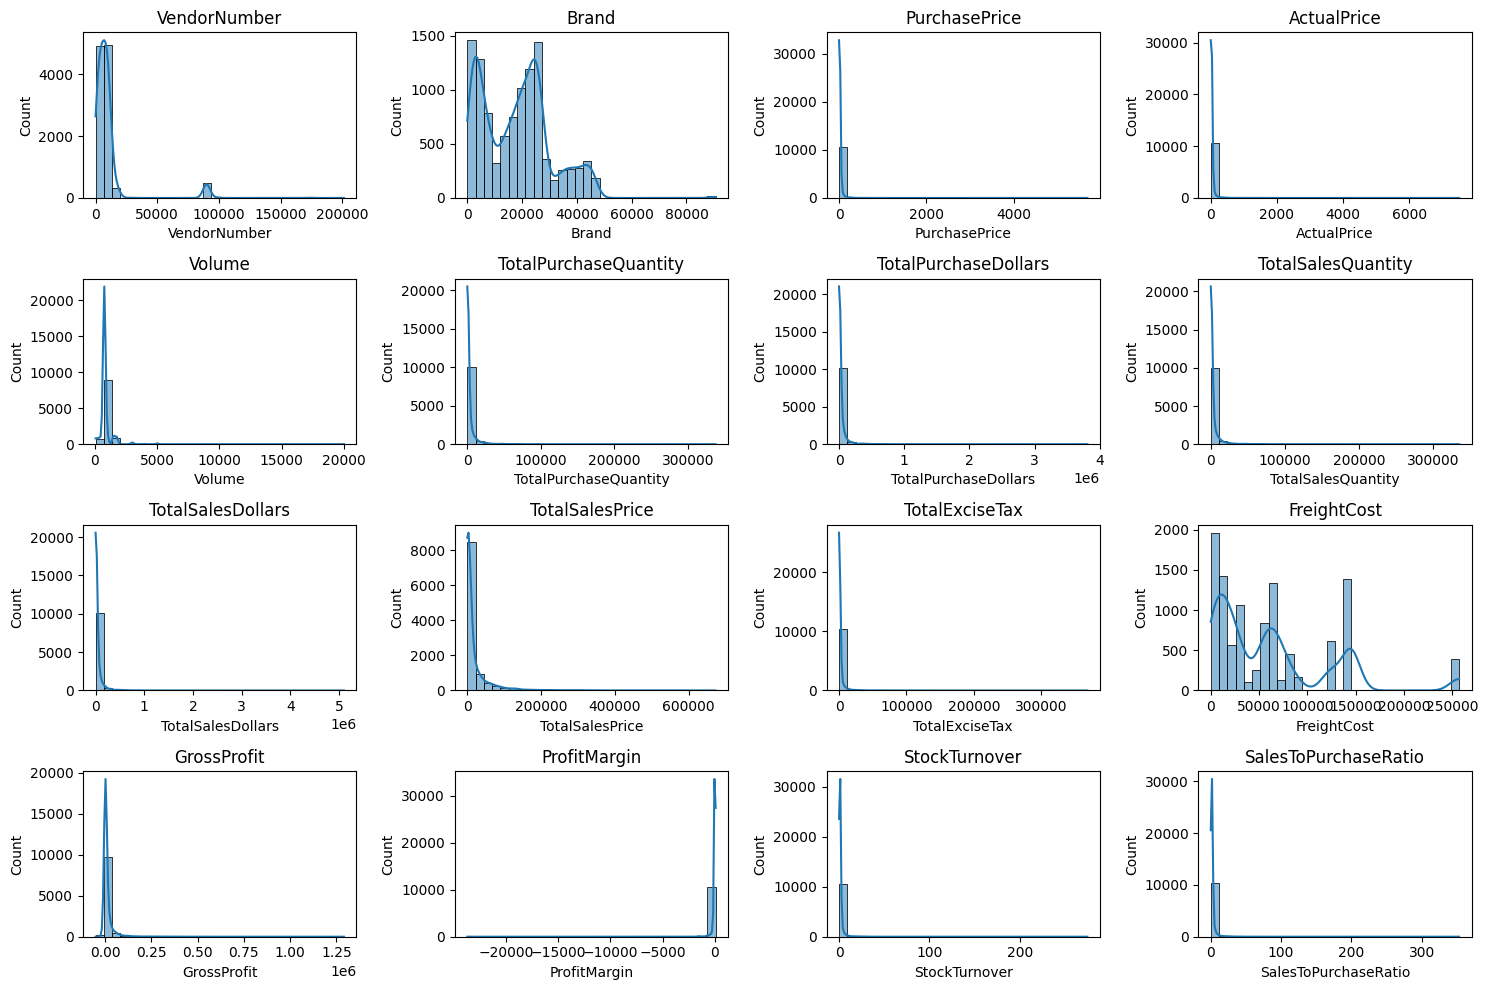

In [37]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
  plt.subplot(4, 4, i+1) # Adjust grid layout as needed
  sns.histplot(df[col], kde=True, bins=30)
  plt.title(col)
plt.tight_layout()
plt.show()

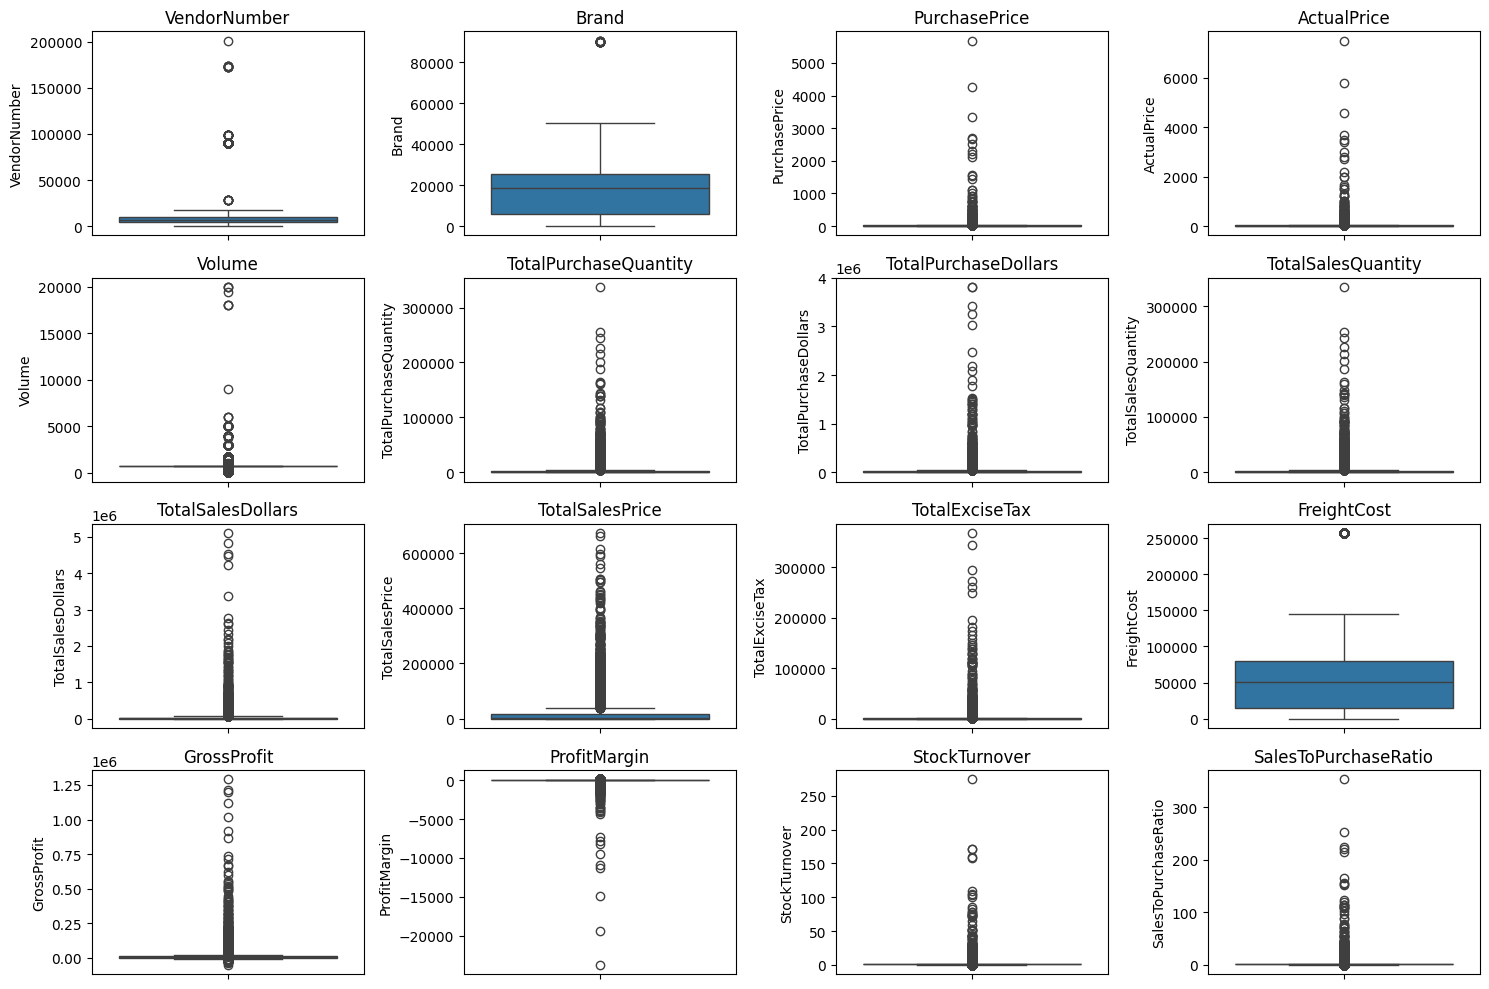

In [38]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
  plt.subplot(4, 4, i+1) # Adjust grid layout as needed
  sns.boxplot(y  = df[col])
  plt.title(col)
plt.tight_layout()
plt.show()

In [39]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("/content/inventory.db")

# Let's filter the data by removing inconsistencies
df = pd.read_sql_query("""
    SELECT *
    FROM vendor_sales_summary
    WHERE GrossProfit > 0
      AND ProfitMargin > 0
      AND TotalSalesQuantity > 0
""", conn)

conn.close()

display(df.head())

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5.101920e+06,672819.31,260999.20,68601.68,1290667.91,25.297693,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4.819073e+06,561512.37,294438.66,144929.24,1015032.27,21.062810,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4.538121e+06,461140.15,343854.07,123780.22,1119816.92,24.675786,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4.475973e+06,420050.01,368242.80,257032.07,1214774.94,27.139908,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4.223108e+06,545778.28,249587.83,257032.07,1199901.61,28.412764,0.983556,1.396897


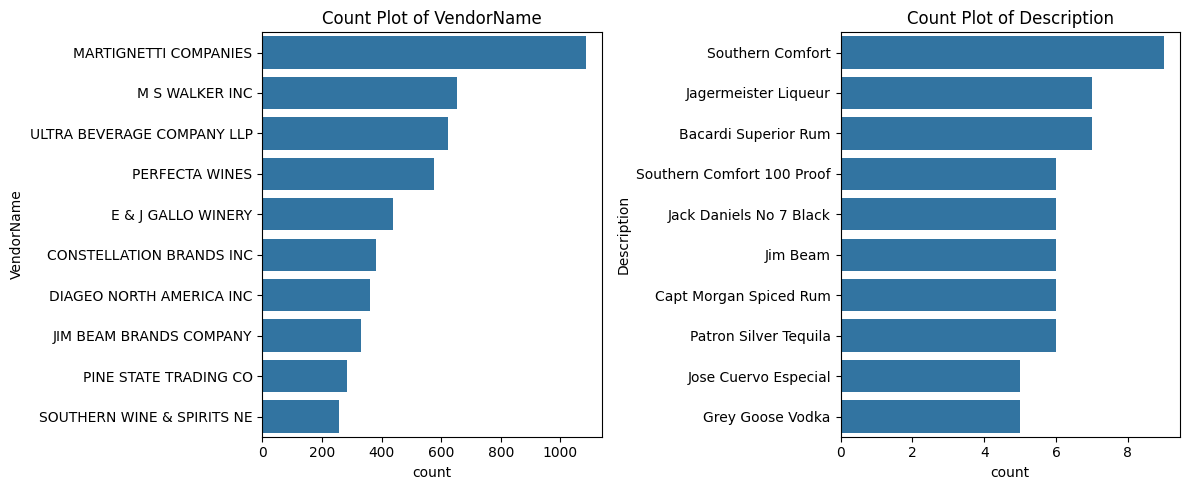

In [40]:
# Count Plots for Categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
  plt.subplot(1, 2, i+1)
  sns.countplot(y=df [col], order=df [col].value_counts() . index [ : 10] )
  plt.title(f"Count Plot of {col}")
plt.tight_layout()
plt.show()

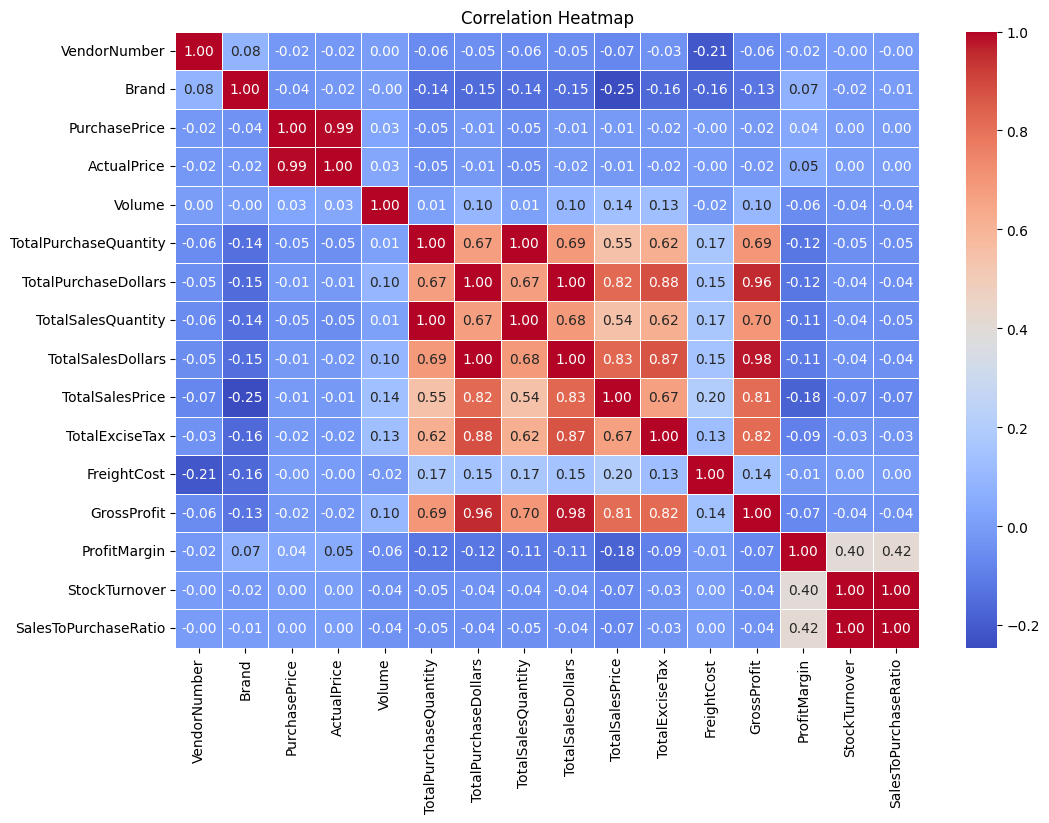

In [41]:
# Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df [numerical_cols].corr()
sns. heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

In [42]:
brand_performance = df.groupby('Description').agg({
            'TotalSalesDollars': 'sum',
            'ProfitMargin':'mean'}). reset_index()
brand_performance

,Description,TotalSalesDollars,ProfitMargin
0,(RI) 1,21519.09,18.060661
1,.nparalleled Svgn Blanc,1094.63,29.978166
2,10 Span Cab Svgn CC,2703.89,20.937612
3,10 Span Chard CC,3325.56,27.806445
4,10 Span Pnt Gris Monterey Cy,2082.22,32.226182
...,...,...,...
7702,Zorvino Vyds Sangiovese,10579.03,29.525675
7703,Zuccardi Q Malbec,1639.18,23.981503
7704,Zum Rsl,10857.34,32.675038
7705,Zwack Liqueur,227.88,16.653502


In [43]:
low_sales_threshold = brand_performance ['TotalSalesDollars' ]. quantile(0.15)
low_sales_threshold


np.float64(560.299)

In [44]:
high_margin_threshold = brand_performance['ProfitMargin'].quantile(0.85)
high_margin_threshold

np.float64(64.97017552750111)

In [45]:
# Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_threshold) &
    (brand_performance['ProfitMargin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,ProfitMargin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [46]:
brand_performance = brand_performance [brand_performance['TotalSalesDollars']<10000] # for better visualization

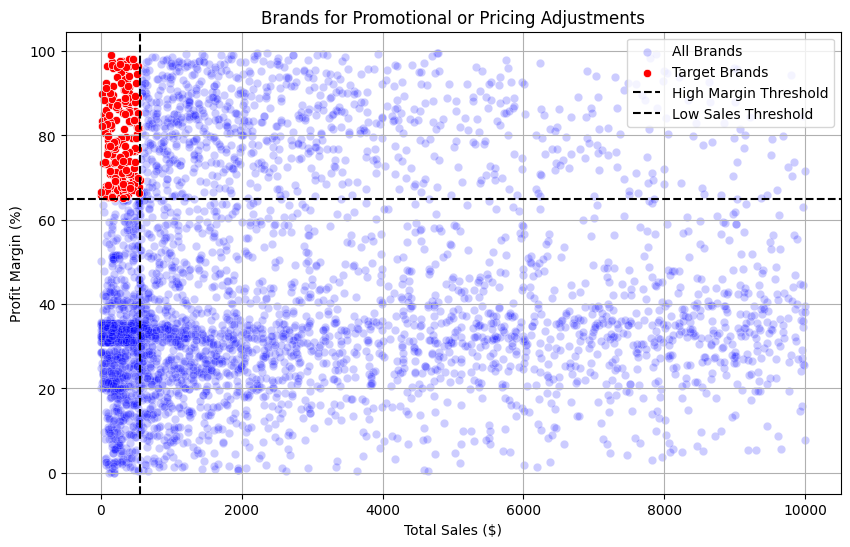

In [47]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin', color="blue", label="All Brands", alpha = 0.2)
sns. scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color="red", label="Target Brands")

plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

Which vendors and brands demonstrate the highest sales performance?

In [48]:

def format_dollars(value):
    if value >= 1_000_000:
        return f" {value / 1_000_000:.2f}M"
    elif value >= 1_000:
        return f" {value / 1_000 :.2f}K"
    else:
        return str(value)

In [49]:
# Top Vendors & Brands by Sales Performance
top_vendors = df.groupby("VendorName") ["TotalSalesDollars"]. sum(). nlargest (10)
top_vendors

,TotalSalesDollars
VendorName,
DIAGEO NORTH AMERICA INC,6.799010e+07
MARTIGNETTI COMPANIES,3.933036e+07
PERNOD RICARD USA,3.206320e+07
JIM BEAM BRANDS COMPANY,3.142302e+07
BACARDI USA INC,2.485482e+07
CONSTELLATION BRANDS INC,2.421875e+07
E & J GALLO WINERY,1.839990e+07
BROWN-FORMAN CORP,1.824723e+07
ULTRA BEVERAGE COMPANY LLP,1.650254e+07


In [50]:
top_brands = df.groupby("Description")["TotalSalesDollars"]. sum().nlargest(10)
top_brands

,TotalSalesDollars
Description,
Jack Daniels No 7 Black,7964746.76
Tito's Handmade Vodka,7399657.58
Grey Goose Vodka,7209608.06
Capt Morgan Spiced Rum,6356320.62
Absolut 80 Proof,6244752.03
Jameson Irish Whiskey,5715759.69
Ketel One Vodka,5070083.56
Baileys Irish Cream,4150122.07
Kahlua,3604858.66


In [51]:
top_brands.apply(lambda x : format_dollars(x))

,TotalSalesDollars
Description,
Jack Daniels No 7 Black,7.96M
Tito's Handmade Vodka,7.40M
Grey Goose Vodka,7.21M
Capt Morgan Spiced Rum,6.36M
Absolut 80 Proof,6.24M
Jameson Irish Whiskey,5.72M
Ketel One Vodka,5.07M
Baileys Irish Cream,4.15M
Kahlua,3.60M


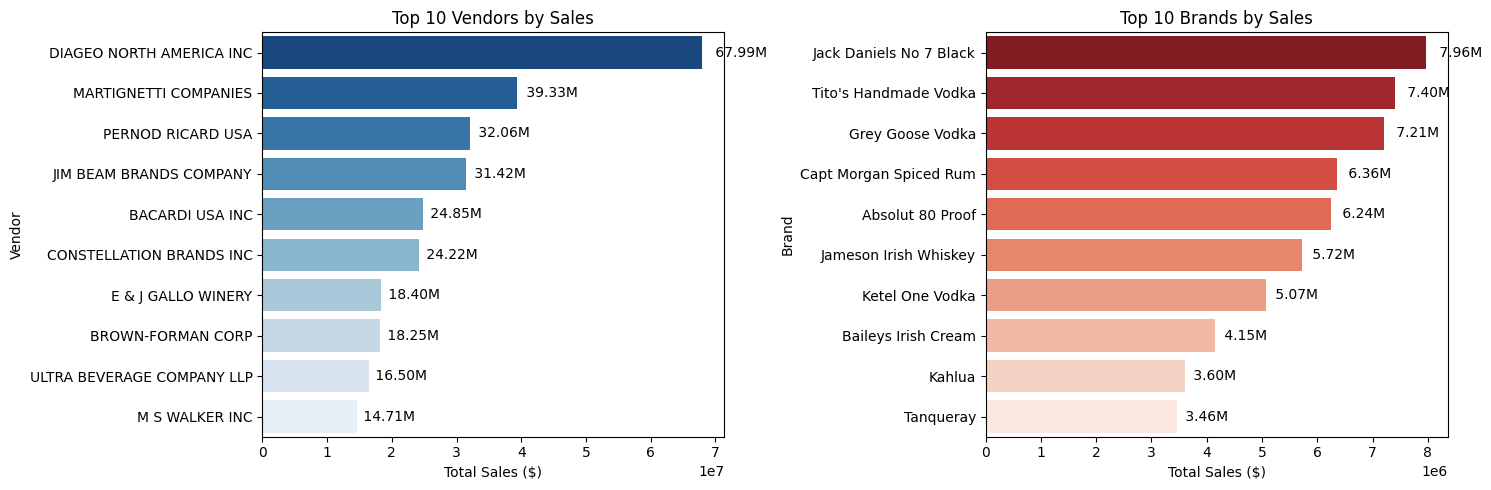

In [52]:
plt.figure(figsize=(15, 5))

# ============================================================
# Plot for Top Vendors
# ============================================================

plt.subplot(1, 2, 1)

ax1 = sns.barplot(
    y=top_vendors.index,
    x=top_vendors.values,
    hue=top_vendors.index,
    palette="Blues_r",
    legend=False
)

plt.title("Top 10 Vendors by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Vendor")

for bar in ax1.patches:
    ax1.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black"
    )


# ============================================================
# Plot for Top Brands
# ============================================================

plt.subplot(1, 2, 2)

ax2 = sns.barplot(
    y=top_brands.index.astype(str),
    x=top_brands.values,
    hue=top_brands.index.astype(str),
    palette="Reds_r",
    legend=False
)

plt.title("Top 10 Brands by Sales")
plt.xlabel("Total Sales ($)")
plt.ylabel("Brand")

for bar in ax2.patches:
    ax2.text(
        bar.get_width() + (bar.get_width() * 0.02),
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black"
    )


plt.tight_layout()
plt.show()

Which vendors contribute the most to total purchase dollars?

In [53]:
vendor_performance = df.groupby('VendorName').agg({
'TotalPurchaseDollars':'sum',
'GrossProfit': 'sum',
'TotalSalesDollars': 'sum'
}).reset_index()
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [54]:
vendor_performance ['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/ vendor_performance['TotalPurchaseDollars'].sum()
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53,0.000001
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94,0.000084
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81,0.000038
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16,0.000003
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53,0.000340
...,...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13,0.000139
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83,0.000971
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20,0.019121
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28,0.016932


In [55]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution%', ascending = False), 2)
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,0.16
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,0.08
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,0.08
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,0.08
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,0.06
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
107,UNCORKED,118.74,58.20,176.94,0.00
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


In [56]:
# Display Top 10 Vendors
top_vendors = vendor_performance.head(10).copy()

top_vendors["TotalSalesDollars"] = (
    top_vendors["TotalSalesDollars"].apply(format_dollars)
)

top_vendors["TotalPurchaseDollars"] = (
    top_vendors["TotalPurchaseDollars"].apply(format_dollars)
)

top_vendors["GrossProfit"] = (
    top_vendors["GrossProfit"].apply(format_dollars)
)

display(top_vendors)

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.08
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,0.08
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.08
6,BACARDI USA INC,17.43M,7.42M,24.85M,0.06
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,0.04
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.04
53,M S WALKER INC,9.76M,4.94M,14.71M,0.03


In [57]:
top_vendors['PurchaseContribution%'].sum()

np.float64(0.6600000000000001)

In [58]:
top_vendors['Cumulative_Contribution%'] = top_vendors ['PurchaseContribution%'].cumsum()
top_vendors

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%,Cumulative_Contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,0.16,0.16
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,0.08,0.24
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,0.08,0.32
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,0.08,0.40
6,BACARDI USA INC,17.43M,7.42M,24.85M,0.06,0.46
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,0.05,0.51
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,0.04,0.55
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,0.04,0.59
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,0.04,0.63
53,M S WALKER INC,9.76M,4.94M,14.71M,0.03,0.66


In [59]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/ vendor_performance['TotalPurchaseDollars'].sum()*100
vendor_performance

,VendorName,TotalPurchaseDollars,GrossProfit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.300334
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.297719
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.760548
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.644435
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.671926
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.000042
107,UNCORKED,118.74,58.20,176.94,0.000039
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.000025
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.000018


In [60]:
print(top_vendors.columns.tolist())

['VendorName', 'TotalPurchaseDollars', 'GrossProfit', 'TotalSalesDollars', 'PurchaseContribution%', 'Cumulative_Contribution%']


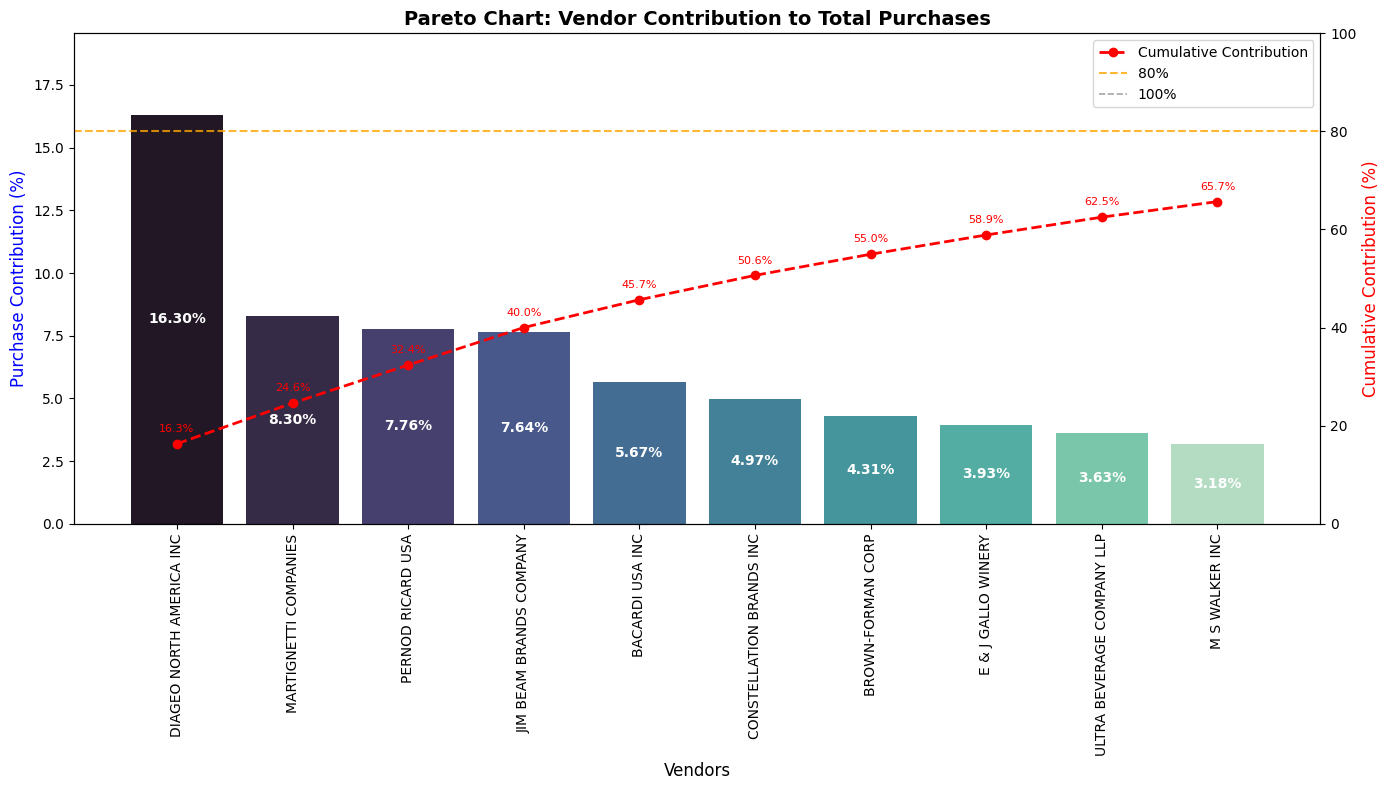

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --------------------------------------------------
# 1. Calculate Purchase Contribution %
# --------------------------------------------------

# Make sure TotalPurchaseDollars is numeric
vendor_performance['TotalPurchaseDollars'] = pd.to_numeric(
    vendor_performance['TotalPurchaseDollars'],
    errors='coerce'
)

vendor_performance['PurchaseContribution%'] = (
    vendor_performance['TotalPurchaseDollars']
    / vendor_performance['TotalPurchaseDollars'].sum()
) * 100


# --------------------------------------------------
# 2. Sort vendors by Purchase Contribution
# --------------------------------------------------

vendor_performance = vendor_performance.sort_values(
    by='PurchaseContribution%',
    ascending=False
).reset_index(drop=True)


# --------------------------------------------------
# 3. Calculate Cumulative Contribution %
# --------------------------------------------------

vendor_performance['Cumulative_Contribution%'] = (
    vendor_performance['PurchaseContribution%'].cumsum()
)


# --------------------------------------------------
# 4. Select top vendors
# --------------------------------------------------

# Change 20 to whatever number of vendors you want
top_vendors = vendor_performance.head(10).copy()


# --------------------------------------------------
# 5. Prepare values for plotting
# --------------------------------------------------

# IMPORTANT:
# These values are ALREADY percentages.
# Do NOT multiply by 100 again.

purchase_pct = top_vendors['PurchaseContribution%']
cumulative_pct = top_vendors['Cumulative_Contribution%']


# --------------------------------------------------
# 6. Create figure
# --------------------------------------------------

fig, ax1 = plt.subplots(figsize=(14, 8))


# --------------------------------------------------
# 7. Bar chart
# --------------------------------------------------

sns.barplot(
    data=top_vendors,
    x='VendorName',
    y='PurchaseContribution%',
    hue='VendorName',
    palette='mako',
    legend=False,
    ax=ax1
)


# --------------------------------------------------
# 8. Add percentage labels inside bars
# --------------------------------------------------

for i, value in enumerate(purchase_pct):

    ax1.text(
        i,
        value / 2,
        f'{value:.2f}%',
        ha='center',
        va='center',
        fontsize=10,
        color='white',
        fontweight='bold'
    )


# --------------------------------------------------
# 9. Create second Y-axis for cumulative %
# --------------------------------------------------

ax2 = ax1.twinx()


# --------------------------------------------------
# 10. Cumulative contribution line
# --------------------------------------------------

ax2.plot(
    range(len(top_vendors)),
    cumulative_pct,
    color='red',
    marker='o',
    linestyle='dashed',
    linewidth=2,
    markersize=6,
    label='Cumulative Contribution'
)


# --------------------------------------------------
# 11. X-axis labels
# --------------------------------------------------

ax1.set_xticks(range(len(top_vendors)))

ax1.set_xticklabels(
    top_vendors['VendorName'],
    rotation=90,
    ha='center'
)


# --------------------------------------------------
# 12. Axis labels
# --------------------------------------------------

ax1.set_xlabel('Vendors', fontsize=12)

ax1.set_ylabel(
    'Purchase Contribution (%)',
    color='blue',
    fontsize=12
)

ax2.set_ylabel(
    'Cumulative Contribution (%)',
    color='red',
    fontsize=12
)


# --------------------------------------------------
# 13. Title
# --------------------------------------------------

ax1.set_title(
    'Pareto Chart: Vendor Contribution to Total Purchases',
    fontsize=14,
    fontweight='bold'
)


# --------------------------------------------------
# 14. Set Y-axis limits
# --------------------------------------------------

ax1.set_ylim(
    0,
    purchase_pct.max() * 1.2
)

ax2.set_ylim(
    0,
    100
)


# --------------------------------------------------
# 15. 80% reference line
# --------------------------------------------------

ax2.axhline(
    y=80,
    color='orange',
    linestyle='--',
    linewidth=1.5,
    alpha=0.8,
    label='80%'
)


# --------------------------------------------------
# 16. 100% reference line
# --------------------------------------------------

ax2.axhline(
    y=100,
    color='gray',
    linestyle='--',
    linewidth=1.2,
    alpha=0.7,
    label='100%'
)


# --------------------------------------------------
# 17. Add cumulative percentage labels
# --------------------------------------------------

for i, value in enumerate(cumulative_pct):

    ax2.text(
        i,
        value + 2,
        f'{value:.1f}%',
        ha='center',
        va='bottom',
        fontsize=8,
        color='red'
    )


# --------------------------------------------------
# 18. Legend
# --------------------------------------------------

ax2.legend(
    loc='upper right'
)


# --------------------------------------------------
# 19. Improve layout
# --------------------------------------------------

plt.tight_layout()

plt.show()

How much of total procurement is dependent on the top vendors?

In [62]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors['PurchaseContribution%'].sum(), 2) } %")

Total Purchase Contribution of top 10 vendors is 65.69 %


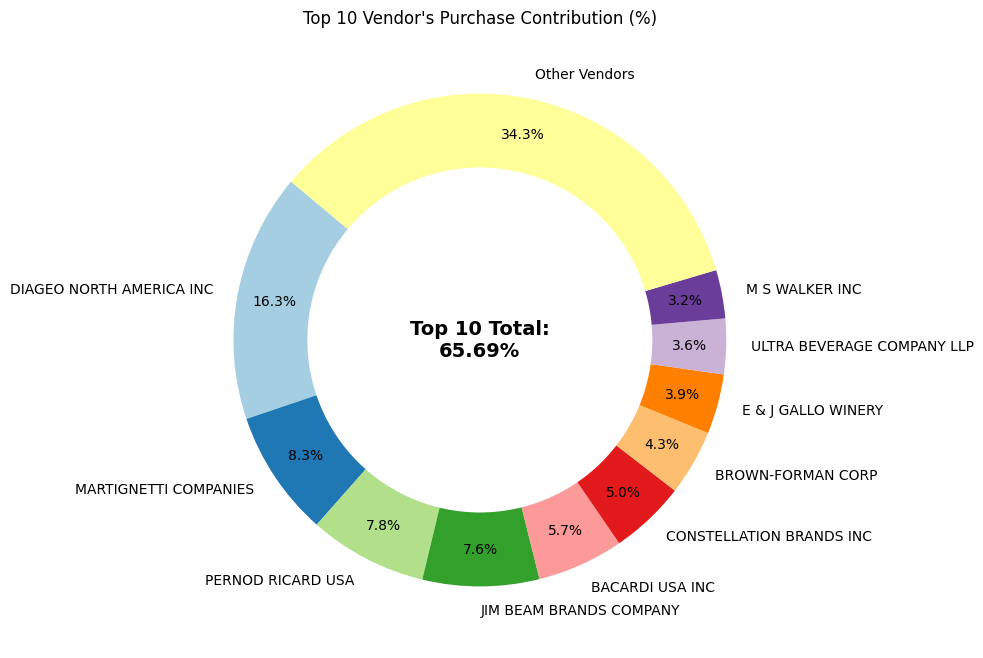

In [63]:
vendors = list(top_vendors['VendorName'].values)
purchase_contributions = list(top_vendors['PurchaseContribution%'].values)

total_contribution = sum(purchase_contributions)
remaining_contribution = 100 - total_contribution

# Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))

wedges, texts, autotexts = ax.pie(
    purchase_contributions,
    labels=vendors,
    autopct='%1.1f%%',
    startangle=140,
    pctdistance=0.85,
    colors=plt.cm.Paired.colors
)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(
    0, 0,
    f"Top 10 Total:\n{total_contribution:.2f}%",
    fontsize=14,
    fontweight='bold',
    ha='center',
    va='center'
)

plt.title("Top 10 Vendor's Purchase Contribution (%)")
plt.show()

Does purchasing in bulk reduce the unit price, and what is the optimal purchase volume for cost savings?

In [64]:
df['UnitPurchasePrice'] = df ['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [65]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [66]:
df.groupby('OrderSize', observed=False)[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.057543
Medium,15.486414
Large,10.777625


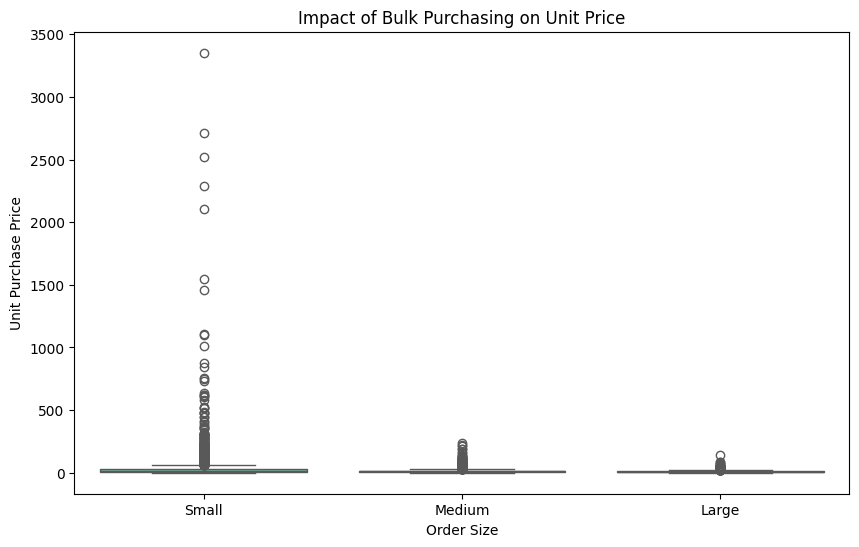

In [67]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="OrderSize",
    y="UnitPurchasePrice",
    hue="OrderSize",
    palette="Set2",
    legend=False
)

plt.title("Impact of Bulk Purchasing on Unit Price")
plt.xlabel("Order Size")
plt.ylabel("Unit Purchase Price")

plt.show()

In [68]:
df [df['StockTurnover' ]<1] . groupby( 'VendorName' ) [ [ 'StockTurnover' ]] . mean( ) . sort_values( 'StockTurnover', ascending = True) . head (10)

,StockTurnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors.

In [69]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold] ["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold] ["ProfitMargin"].dropna()

In [70]:
low_vendors

,ProfitMargin
5631,4.111764
5652,6.145626
5701,12.007271
5704,1.677308
5724,7.239599
...,...
8560,83.448276
8561,96.436186
8562,25.252525
8563,98.974037


In [71]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data))

    t_critical = stats.t.ppf(
        (1 + confidence) / 2,
        df=len(data) - 1
    )

    margin_of_error = t_critical * std_err

    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [72]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.17
Low Vendors 95% CI: (40.48, 42.62), Mean: 41.55


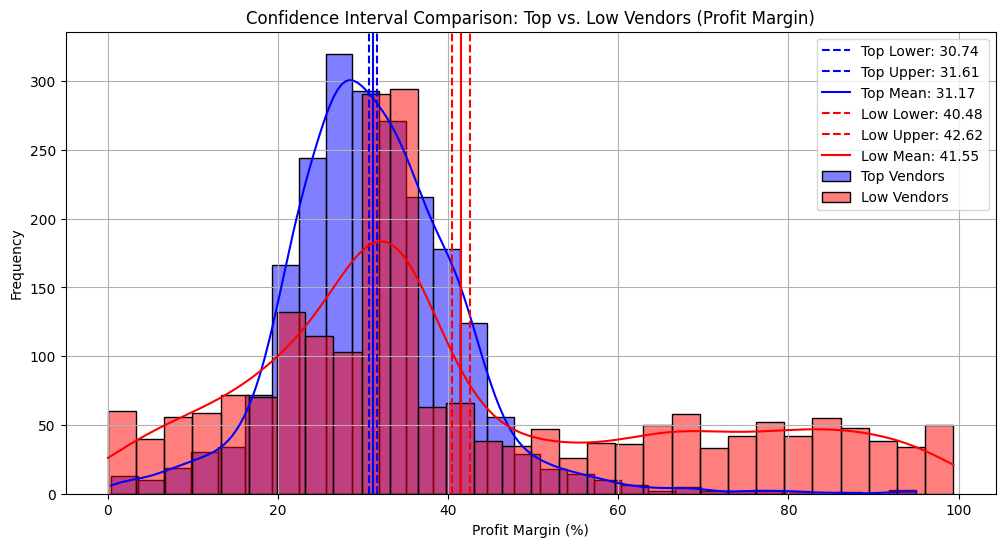

In [73]:
plt.figure(figsize=(12, 6))

# Top Vendors
sns.histplot(
    top_vendors,
    kde=True,
    color="blue",
    bins=30,
    alpha=0.5,
    label="Top Vendors"
)

plt.axvline(
    top_lower,
    color="blue",
    linestyle="--",
    label=f"Top Lower: {top_lower:.2f}"
)

plt.axvline(
    top_upper,
    color="blue",
    linestyle="--",
    label=f"Top Upper: {top_upper:.2f}"
)

plt.axvline(
    top_mean,
    color="blue",
    linestyle="-",
    label=f"Top Mean: {top_mean:.2f}"
)

# Low Vendors
sns.histplot(
    low_vendors,
    kde=True,
    color="red",
    bins=30,
    alpha=0.5,
    label="Low Vendors"
)

plt.axvline(
    low_lower,
    color="red",
    linestyle="--",
    label=f"Low Lower: {low_lower:.2f}"
)

plt.axvline(
    low_upper,
    color="red",
    linestyle="--",
    label=f"Low Upper: {low_upper:.2f}"
)

plt.axvline(
    low_mean,
    color="red",
    linestyle="-",
    label=f"Low Mean: {low_mean:.2f}"
)

plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
import sqlite3
import pandas as pd

conn = sqlite3.connect('/content/inventory.db')

tables = pd.read_sql_query("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
    ORDER BY name;
""", conn)

tables

,name
0,begin_inventory
1,end_inventory
2,purchase_prices
3,purchases
4,sales
5,sales_summary
6,vendor_invoice
7,vendor_sales_summary


Download datasets

In [ ]:
import sqlite3
import csv
import os
import zipfile
from google.colab import files

DB_PATH = "/content/inventory.db"
OUTPUT_DIR = "/content/inventory_tables"
ZIP_PATH = "/content/inventory_tables_for_powerbi.zip"

# Create output folder
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Connect to SQLite
conn = sqlite3.connect(DB_PATH)
cursor = conn.cursor()

# Get ALL user tables
cursor.execute("""
    SELECT name
    FROM sqlite_master
    WHERE type = 'table'
      AND name NOT LIKE 'sqlite_%'
    ORDER BY name
""")

tables = [row[0] for row in cursor.fetchall()]

print(f"Found {len(tables)} tables:")
for table in tables:
    print(" -", table)

# Export each table in chunks
for table in tables:
    print(f"\nExporting: {table}")

    table_cursor = conn.cursor()
    table_cursor.execute(f'SELECT * FROM "{table}"')

    # Column names
    columns = [description[0] for description in table_cursor.description]

    csv_path = os.path.join(OUTPUT_DIR, f"{table}.csv")

    row_count = 0

    with open(csv_path, "w", newline="", encoding="utf-8-sig") as f:
        writer = csv.writer(f)

        # Header
        writer.writerow(columns)

        # Read only 10,000 rows at a time
        while True:
            rows = table_cursor.fetchmany(10000)

            if not rows:
                break

            writer.writerows(rows)
            row_count += len(rows)

            print(f"  {row_count:,} rows...", end="\r")

    table_cursor.close()

    print(f"  ✓ {table}: {row_count:,} rows exported")

conn.close()

# Create ZIP without loading CSVs into RAM
print("\nCreating ZIP...")

with zipfile.ZipFile(
    ZIP_PATH,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as zipf:

    for filename in os.listdir(OUTPUT_DIR):
        filepath = os.path.join(OUTPUT_DIR, filename)

        if os.path.isfile(filepath):
            zipf.write(filepath, arcname=filename)

print("\n===================================")
print("EXPORT COMPLETE")
print("===================================")
print(f"Tables exported: {len(tables)}")
print(f"ZIP file: {ZIP_PATH}")

# Download the ZIP
files.download(ZIP_PATH)

Found 8 tables:
 - begin_inventory
 - end_inventory
 - purchase_prices
 - purchases
 - sales
 - sales_summary
 - vendor_invoice
 - vendor_sales_summary

Exporting: begin_inventory
  ✓ begin_inventory: 206,529 rows exported

Exporting: end_inventory
  ✓ end_inventory: 224,489 rows exported

Exporting: purchase_prices
  ✓ purchase_prices: 12,261 rows exported

Exporting: purchases
  ✓ purchases: 2,372,474 rows exported

Exporting: sales
  ✓ sales: 12,825,363 rows exported

Exporting: sales_summary
  ✓ sales_summary: 12,489 rows exported

Exporting: vendor_invoice
  ✓ vendor_invoice: 5,543 rows exported

Exporting: vendor_sales_summary
  ✓ vendor_sales_summary: 10,692 rows exported

Creating ZIP...

EXPORT COMPLETE
Tables exported: 8
ZIP file: /content/inventory_tables_for_powerbi.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>